In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../Data/ai_job_dataset.csv")
# Initial overview
print(f"Dataset Shape: {df.shape}")
print(f"\nMemory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print("\nFirst few rows:")
df.head()

# 국가, 직군, 연차

Dataset Shape: (15000, 19)

Memory Usage: 2.17 MB

First few rows:


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [4]:
# 숫자형 변환
df['salary_usd'] = pd.to_numeric(df['salary_usd'], errors='coerce')

In [5]:
# 1. salary_usd 기반 라벨링 (low, mid, high)
# 연봉 구간에 따른 라벨 추가
def label_salary(salary):
    if salary <= 70000:
        return 'low'
    elif salary <= 140000:
        return 'mid'
    else:
        return 'high'

df['salary_label'] = df['salary_usd'].apply(label_salary)

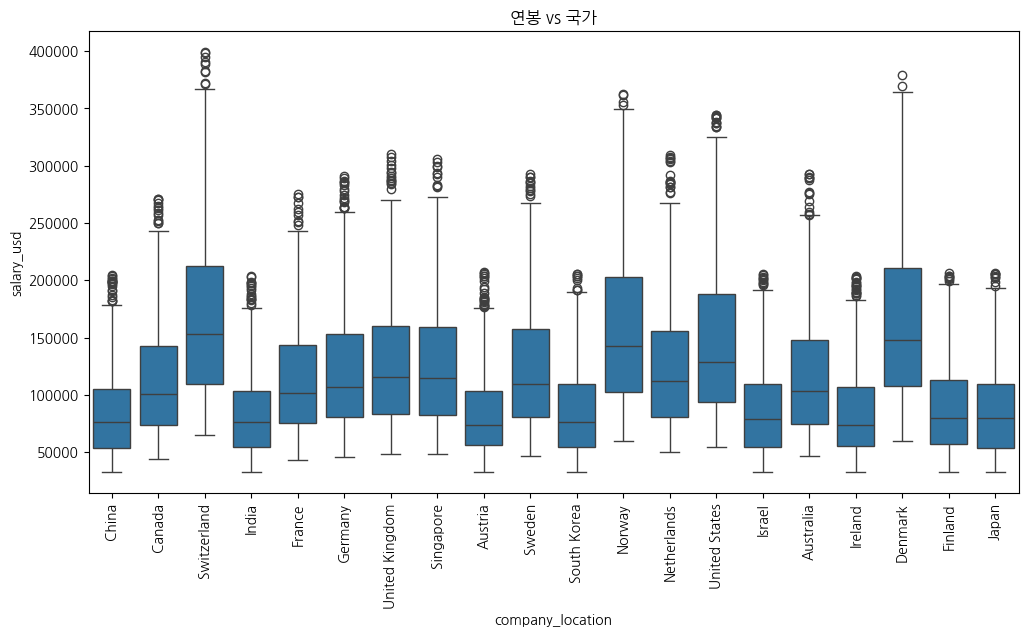

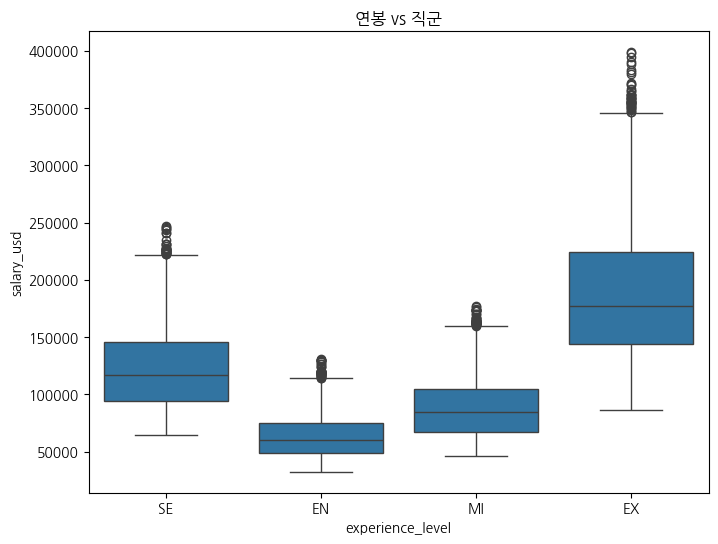

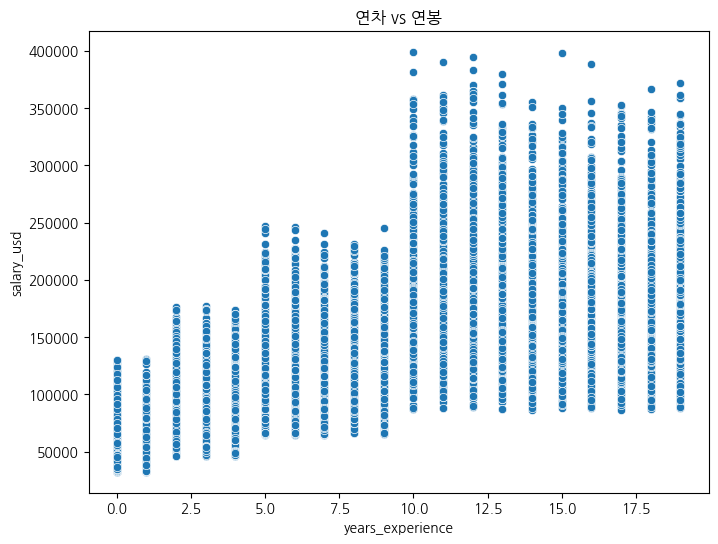

In [9]:
# 

import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import koreanize_matplotlib

# 국가별 연봉 분포
plt.figure(figsize=(12, 6))
sns.boxplot(x='company_location', y='salary_usd', data=df)
plt.xticks(rotation=90)
plt.title("연봉 vs 국가")
plt.show()

# 경력레벨별 연봉 분포
plt.figure(figsize=(8, 6))
sns.boxplot(x='experience_level', y='salary_usd', data=df)
plt.title("연봉 vs 직군")
plt.show()

# 연차 vs 연봉 산점도
plt.figure(figsize=(8, 6))
sns.scatterplot(x='years_experience', y='salary_usd', data=df)
plt.title("연차 vs 연봉")
plt.show()

In [10]:
# 2. 필요한 feature 추출

df_subset = df[['company_location', 'experience_level', 'years_experience', 'salary_label']].dropna()

In [11]:
# 3. 원핫인코딩 + 스케일링

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 컬럼 정의
cat_cols = ['company_location', 'experience_level']
num_cols = ['years_experience']

# 전처리 파이프라인
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])
X_processed = preprocessor.fit_transform(df_subset.drop('salary_label', axis=1))

In [12]:
# 4. PCA로 2차원 축소

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

In [13]:
# 5. k=3으로 Kmeans clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df_subset['cluster'] = clusters

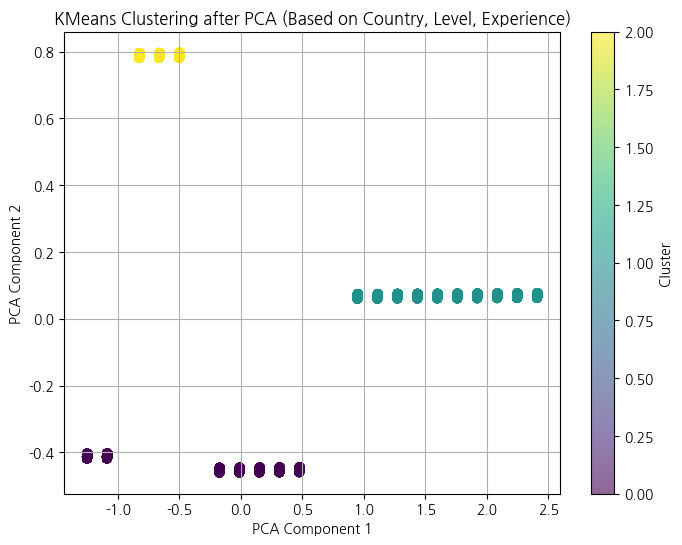

In [14]:
# 6. 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KMeans Clustering after PCA (Based on Country, Level, Experience)")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [15]:
pd.crosstab(df_subset['salary_label'], df_subset['cluster'])

cluster,0,1,2
salary_label,,,
high,1074,2909,137
low,2603,0,1119
mid,3782,851,2525


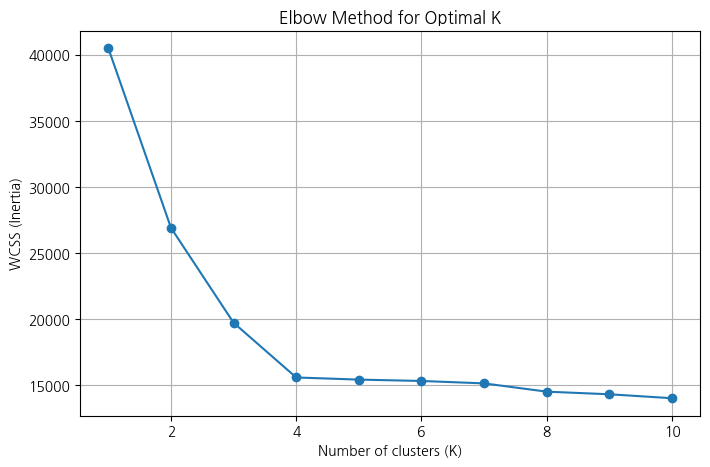

In [16]:
# 최적의 K값 찾기

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # Within-cluster sum of squares

# 1~10까지 K값에 대해 반복
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

# 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

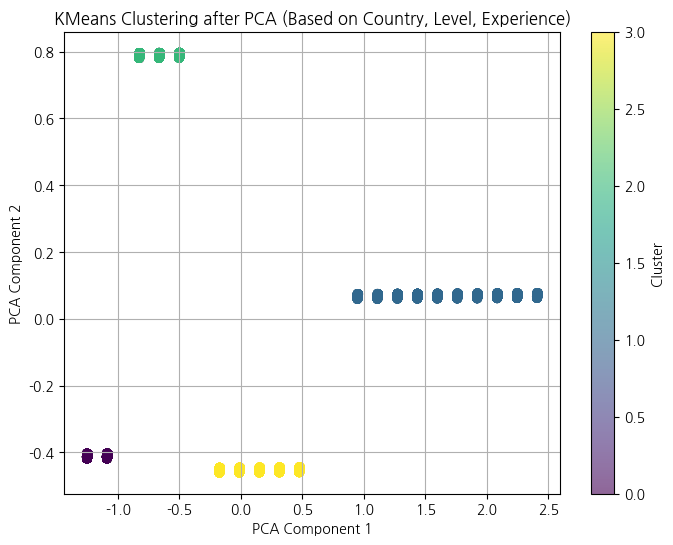

In [18]:
# 6. k=4으로 Kmeans clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df_subset['cluster'] = clusters



plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KMeans Clustering after PCA (Based on Country, Level, Experience)")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [19]:
df_subset.groupby('cluster')[['years_experience']].mean()

,years_experience
cluster,
0,0.491662
1,14.480585
2,3.014811
3,6.983160


클러스터
평균 연차 (years_experience)
해석
0
0.49년
🔰 초급자 집단 (신입~1년차)
2
3.01년
🧱 주니어급 (~3년차)
3
6.98년
🔧 중급자 (~7년차)
1
14.48년
🏆 고급/시니어 (10년 이상)


In [20]:
df_subset['cluster'] = clusters  # 클러스터 번호가 저장된 변수
df_subset = df_subset.join(df[['salary_usd']], how='left')
df_subset.groupby('cluster')['salary_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,3718.0,63133.377084,18558.096806,32519.0,48516.0,60373.5,74866.5,131006.0
1,3760.0,187723.647340,59316.742112,86536.0,143966.0,177512.0,224549.5,399095.0
2,3781.0,87955.471833,25543.109400,45900.0,67621.0,84641.0,104483.0,177470.0
3,3741.0,122187.657845,35261.617316,64824.0,94173.0,116907.0,145315.0,247271.0


In [22]:
df_subset.groupby('cluster')['company_location'].value_counts(normalize=True)


cluster  company_location
0        Australia           0.054868
         China               0.053254
         South Korea         0.052717
         Ireland             0.052448
         Switzerland         0.052179
                               ...   
3        Norway              0.048383
         Ireland             0.047848
         United States       0.047581
         Netherlands         0.045977
         Australia           0.045710
Name: proportion, Length: 80, dtype: float64

In [23]:
df_subset.groupby('cluster')['experience_level'].value_counts(normalize=True)

cluster  experience_level
0        EN                  1.0
1        EX                  1.0
2        MI                  1.0
3        SE                  1.0
Name: proportion, dtype: float64